In [400]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Creación del laberinto
----------------------------

In [401]:
size_n = 15
size = (size_n, size_n)
inicio_global = (0, 0)
meta_global = (size_n-1, size_n-1)
plt.close('all')

def crear_laberinto(size, porcentaje_paredes=20, inicio=(0,0), meta=None):
    laberinto = np.zeros((size, size)) #Tablero vacío
    numero_paredes = int((size * size) * porcentaje_paredes / 100) #Cantidad de paredes

    #Ubicar paredes
    for pared in range(numero_paredes):
        x, y = random.randint(0, size-1), random.randint(0, size-1)

        #Que la meta o el inicio no sean paredes
        if (x, y) != inicio and (meta is None or (x,y) != meta):
            laberinto[x,y] = 1

    #Ubicar la meta
    if meta:
        laberinto[meta] = 9 #Representar la meta con 9
    else:
        #Ubicar la meta si no está especificado
        while True:
            x, y = random.randint(0, size-1), random.randint(0, size-1)
            if laberinto[x,y] == 0 and (x, y) != inicio:
                laberinto[x,y] = 9
                break
    return laberinto

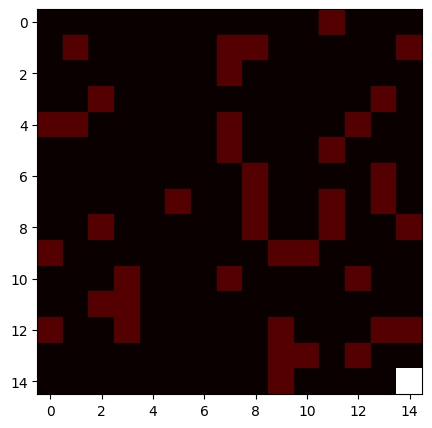

In [402]:
#Visualización de laberinto
def ver_laberinto(laberinto):
    plt.figure(figsize=(5,5))
    plt.imshow(laberinto, cmap="hot", interpolation="nearest")

#LABERINTO DEFINITIVO
laberinto = crear_laberinto(size_n,20,inicio_global,meta_global)
ver_laberinto(laberinto)

## Modelo de aprendizaje (Q-Learning)
---------------------------


In [403]:
acciones= [(-1, 0), #arriba
           (1,0), #abajo
           (0, -1), #izquierda
           (0, 1) #derecha
           ]
#Creación de Q
estados_posibles= size[0] * size[1]
num_acciones = len(acciones)
Q = np.zeros((estados_posibles, num_acciones))

In [404]:
#Localizar a nuestro agente
def estado_a_indice(estado):
    return estado[0] * size[1] + estado[1]

In [405]:
#Parámetros del aprendizaje
alpha = 0.1
gamma = 0.99
epsilon = 0.9
episodios = 10000

In [406]:
#Elección de acciones
def elegir_accion(estado):
    if random.uniform(0,1) < epsilon:
        return random.choice(range(num_acciones))   
    else:
        return np.argmax(Q[estado_a_indice(estado)])

In [407]:
def aplicar_accion(estado,accion_idx):
    accion = acciones[accion_idx]

    #Calculamos la posicion teorica sin el mundo toroidal
    pos_teorica = np.add(estado, accion)

    #Aplicamos la lógica toroidal, el % size asegura que siempre esté en el tablero
    nuevo_estado = tuple(pos_teorica % size)

    #Comprobamos si la posición teorica es distinta a la toroidal
    cruzo_frontera = (tuple(pos_teorica) != nuevo_estado)

    #SISTEMA DE RECOMPENSAS

    #Si quiere ir a una pared o no moverse
    if laberinto[nuevo_estado] == 1 or nuevo_estado == estado:
        return estado, -20, False

    #En caso de que se quiera salir de los limites del laberinto
    if cruzo_frontera:
        return nuevo_estado, -900, False

    #Si llega a la meta
    elif laberinto[nuevo_estado] == 9:
        return nuevo_estado, 100,True


    #Si se quiere mover y no hay pared
    else:
        return nuevo_estado, -1, False

In [408]:
pasos_maximos = 300
for episodio in range(episodios):
    pasos = 0
    if epsilon >= 0.01: epsilon *= 0.9995
    inicio = (0,0)
    estado = inicio
    terminado = False
    while not terminado and pasos < pasos_maximos:
        #Parametros necesarios para la formula:
        idx_estado = estado_a_indice(estado)
        accion_idx = int(elegir_accion(estado))
        nuevo_estado,recompensa,terminado = aplicar_accion(estado,accion_idx)
        idx_nuevo_estado = estado_a_indice(nuevo_estado)

        #Formula Actualización de Q:
        Q[idx_estado, accion_idx] = Q[idx_estado, accion_idx] + alpha * (recompensa + gamma *np.max(Q[idx_nuevo_estado]) - Q[idx_estado, accion_idx])

        estado = nuevo_estado
        pasos += 1

In [409]:
print(f"Suma de valores en Q: {np.sum(Q)}")

Suma de valores en Q: 387448.3747630464


In [410]:
politica = np.zeros(size,dtype=int)
for i in range(size[0]):
    for j in range(size[1]):
        estado = (i,j)
        idx_estado =estado_a_indice(estado)
        mejor_accion= np.argmax(Q[idx_estado])
        politica[i,j] = mejor_accion
print(politica)
print("Politica aprendida: 0 arriba, 1 abajo, 2 izquierda, 3 derecha")

[[3 3 3 1 1 1 1 2 3 3 1 0 1 2 2]
 [0 0 3 3 1 1 1 0 0 1 1 1 1 2 0]
 [3 3 3 3 3 3 1 0 1 3 1 1 2 2 1]
 [0 0 0 3 3 3 3 3 3 3 1 2 2 0 1]
 [0 0 3 0 0 0 0 0 3 3 1 2 0 1 1]
 [3 3 1 1 1 3 1 0 3 3 1 0 1 2 2]
 [3 3 3 3 1 3 1 1 0 3 3 3 1 0 0]
 [3 3 3 1 1 0 1 1 0 0 0 0 1 0 0]
 [0 1 0 3 1 1 1 1 0 3 0 0 1 2 0]
 [0 3 3 3 3 3 1 3 1 0 0 1 2 2 2]
 [3 0 0 0 3 1 1 0 3 3 3 1 0 1 1]
 [3 1 0 0 3 3 3 3 3 3 3 1 2 2 2]
 [0 1 1 0 3 3 0 0 0 0 3 1 2 0 0]
 [3 3 3 3 3 0 0 0 0 0 0 1 0 1 1]
 [0 3 3 3 0 0 0 0 0 0 3 3 3 3 2]]
Politica aprendida: 0 arriba, 1 abajo, 2 izquierda, 3 derecha


In [411]:
def probar_agente(inicio=(0,0), pasos_limite=50):
    estado = inicio
    camino = [estado] # Guardamos las posiciones para dibujarlas
    total_recompensa = 0

    for _ in range(pasos_limite):
        idx = estado_a_indice(estado)
        # Tomamos la mejor acción según la tabla Q (sin azar)
        accion_idx = np.argmax(Q[idx])

        nuevo_estado, recompensa, terminado = aplicar_accion(estado, accion_idx)

        # Detectar si se teletransportó (Toroidal)
        distancia = np.linalg.norm(np.array(nuevo_estado) - np.array(estado))
        if distancia > 1.5:
            print(f"¡SALTO TOROIDAL! De {estado} a {nuevo_estado}")

        estado = nuevo_estado
        camino.append(estado)
        total_recompensa += recompensa

        if terminado:
            print(f"¡META ALCANZADA! Recompensa total: {total_recompensa}")
            break

    return camino

# Ejecutar la prueba
recorrido = probar_agente()

¡META ALCANZADA! Recompensa total: 71


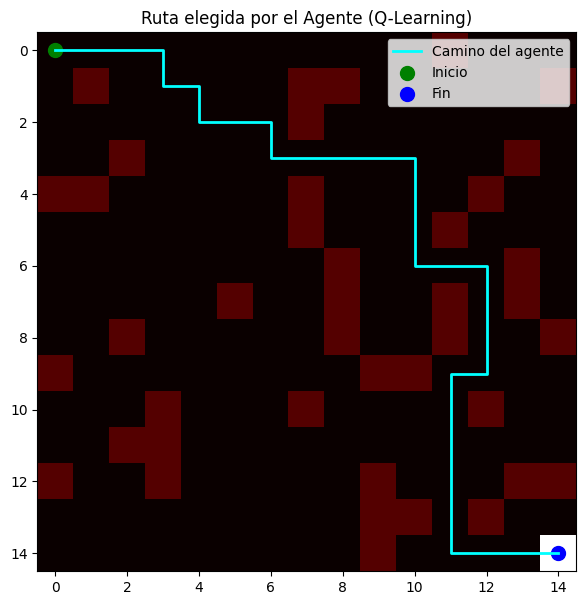

In [412]:
def dibujar_recorrido(laberinto, camino):
    plt.figure(figsize=(7,7))
    plt.imshow(laberinto, cmap="hot")

    # Extraer X e Y del camino
    filas = [p[0] for p in camino]
    cols = [p[1] for p in camino]

    # Dibujar la línea del camino
    plt.plot(cols, filas, color="cyan", linewidth=2, label="Camino del agente")
    plt.scatter(cols[0], filas[0], color="green", s=100, label="Inicio") # Inicio
    plt.scatter(cols[-1], filas[-1], color="blue", s=100, label="Fin") # Fin

    plt.legend()
    plt.title("Ruta elegida por el Agente (Q-Learning)")
    plt.show()

dibujar_recorrido(laberinto, recorrido)